In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **Part 1:**



In [61]:
data = pd.read_csv('data-27.csv')
data.info()
data.describe()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datetime      2924 non-null   object 
 1   open          2924 non-null   float64
 2   high          2924 non-null   float64
 3   low           2924 non-null   float64
 4   close         2924 non-null   float64
 5   volume        2924 non-null   float64
 6   Unnamed: 0.1  2193 non-null   float64
 7   Unnamed: 0    2193 non-null   float64
dtypes: float64(7), object(1)
memory usage: 182.9+ KB


,datetime,open,high,low,close,volume,Unnamed: 0.1,Unnamed: 0
0,2018-01-01 00:00:00,13715.65,13818.55,12750.00,13135.00,6970.441076,NaN,NaN
1,2018-01-02 00:00:00,13135.00,14750.00,12890.02,14580.00,16359.347340,NaN,NaN
2,2018-01-03 00:00:00,14576.87,15473.49,14150.00,14749.97,19457.238601,NaN,NaN
3,2018-01-04 00:00:00,14710.00,15280.00,13918.04,14811.00,18783.876561,NaN,NaN
4,2018-01-05 00:00:00,14805.01,17118.13,14600.00,16579.00,22383.657333,NaN,NaN
...,...,...,...,...,...,...,...,...
2919,2023-12-28 05:30:00,43428.86,43787.57,42241.79,42563.76,35150.524850,2188.0,2188.0
2920,2023-12-29 05:30:00,42563.76,43111.00,41300.00,42066.95,42597.189120,2189.0,2189.0
2921,2023-12-30 05:30:00,42066.94,42612.32,41520.30,42140.28,22906.578180,2190.0,2190.0
2922,2023-12-31 05:30:00,42140.29,42899.00,41965.84,42283.58,23585.916030,2191.0,2191.0


In [62]:
data['SMA'] = data['close'].rolling(window=20).mean()
data['EMA_20'] = data['close'].ewm(span=20, adjust=False).mean()
data['EMA_50'] = data['close'].ewm(span=50, adjust=False).mean()
data.head(60)

,datetime,open,high,low,close,volume,Unnamed: 0.1,Unnamed: 0,SMA,EMA_20,EMA_50
0,2018-01-01 00:00:00,13715.65,13818.55,12750.00,13135.00,6970.441076,NaN,NaN,NaN,13135.000000,13135.000000
1,2018-01-02 00:00:00,13135.00,14750.00,12890.02,14580.00,16359.347340,NaN,NaN,NaN,13272.619048,13191.666667
2,2018-01-03 00:00:00,14576.87,15473.49,14150.00,14749.97,19457.238601,NaN,NaN,NaN,13413.319138,13252.776601
3,2018-01-04 00:00:00,14710.00,15280.00,13918.04,14811.00,18783.876561,NaN,NaN,NaN,13546.431601,13313.883401
4,2018-01-05 00:00:00,14805.01,17118.13,14600.00,16579.00,22383.657333,NaN,NaN,NaN,13835.247639,13441.927189
5,2018-01-06 00:00:00,16579.00,17176.24,16011.21,16769.89,20207.444304,NaN,NaN,NaN,14114.737388,13572.435535
6,2018-01-07 00:00:00,16775.00,17143.13,15610.00,16019.25,14684.026607,NaN,NaN,NaN,14296.119541,13668.389043
7,2018-01-08 00:00:00,16020.58,16500.00,12812.00,14900.00,24892.244119,NaN,NaN,NaN,14353.631966,13716.687512
8,2018-01-09 00:00:00,14900.00,15500.00,14011.05,14803.44,14683.267154,NaN,NaN,NaN,14396.470826,13759.305257
9,2018-01-10 00:00:00,14803.46,14863.93,13131.31,14548.32,18317.225351,NaN,NaN,NaN,14410.932653,13790.247012


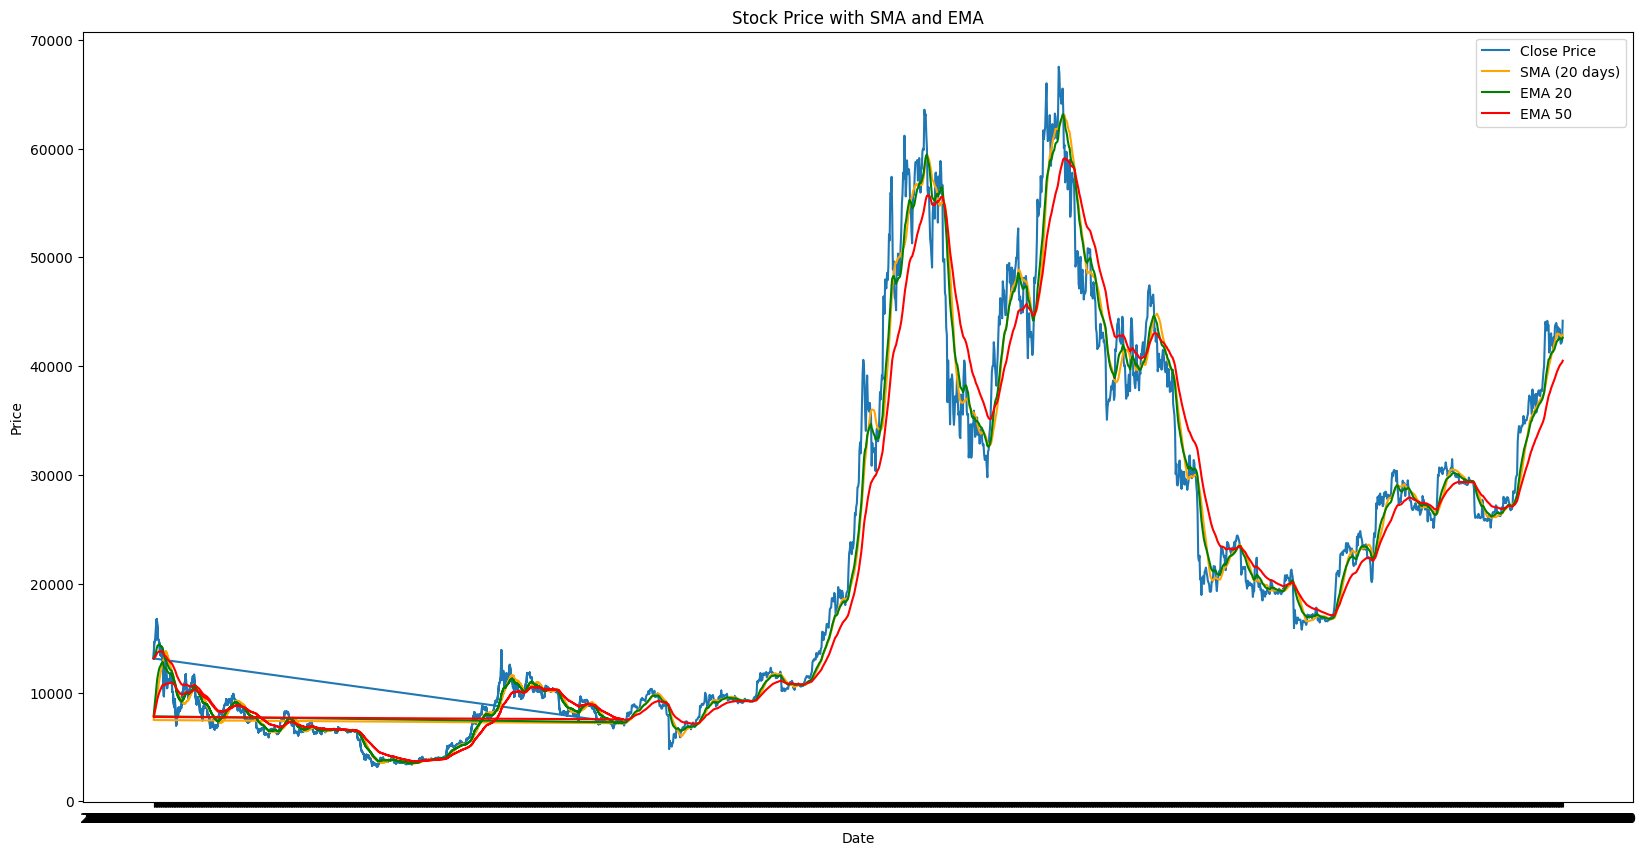

In [63]:
plt.figure(figsize=(20, 10))
plt.plot(data['datetime'], data['close'], label='Close Price', alpha=1)
plt.plot(data['datetime'], data['SMA'], label='SMA (20 days)', color='orange')
plt.plot(data['datetime'], data['EMA_20'], label='EMA 20', color='green')
plt.plot(data['datetime'], data['EMA_50'], label='EMA 50', color='red')
plt.title('Stock Price with SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## **Part 2 :**

In [64]:
data['datetime'] = pd.to_datetime(data['datetime'])
data.set_index('datetime', inplace=True)

volatility = data['close'].resample('6M').std()
volatility_data = volatility.reset_index()
volatility_data.columns = ['Period_End', 'Volatility']

print("Volatility for each 6-month period:")
print(volatility_data)
most_volatile = volatility_data.loc[volatility_data['Volatility'].idxmax()]
print("\n Most Volatile 6-Month Period:")
print(f"Period Ending: {most_volatile['Period_End'].date()}, Std Dev: {most_volatile['Volatility']:.2f}")


Volatility for each 6-month period:
   Period_End    Volatility
0  2018-01-31   2015.271600
1  2018-07-31   1328.840791
2  2019-01-31   1407.786648
3  2019-07-31   2798.572026
4  2020-01-31   1312.245827
5  2020-07-31   1372.755043
6  2021-01-31   8741.749329
7  2021-07-31  10029.363786
8  2022-01-31   7837.139102
9  2022-07-31   8890.239310
10 2023-01-31   2336.555334
11 2023-07-31   2736.763731
12 2024-01-31   6386.320742

 Most Volatile 6-Month Period:
Period Ending: 2021-07-31, Std Dev: 10029.36


<ipython-input-64-5e97f8744dd2>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  volatility = data['close'].resample('6M').std()
